# Assignment No. 01

# Exploratory Data Analysis (EDA) on Titanic Dataset

### Course:
Statistics for Machine Learning and Data Science

### Course Code:
2015111

### Student Name:
Tumbi Mohamed Hamza Sueb

### UIN:
241A015

### Class:
T.E. AI & DS

### Semester:
V

---

## Objective

The objective of this assignment is to perform Exploratory Data Analysis (EDA) on the Titanic dataset using descriptive statistics, data visualization, preprocessing techniques, and sampling methods. The analysis aims to identify patterns, relationships, and data quality issues, and evaluate the suitability of the dataset for Machine Learning.

In [1]:
# Import Required Libraries

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

print("Libraries imported successfully!")

Libraries imported successfully!


# Part A: Dataset Understanding

The Titanic dataset contains demographic and travel-related information about passengers aboard the RMS Titanic. It includes variables such as passenger class, age, gender, fare, family details, and survival status.

This dataset is widely used for classification problems and exploratory data analysis because it contains both numerical and categorical variables along with missing values.

In [2]:
# Load Dataset

df = pd.read_csv("train_and_test2.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
# Display first five rows

df.head()

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0


In [4]:
# Shape of dataset

df.shape

(1309, 28)

## Dataset Information

**Dataset Source:** Kaggle (Modified Titanic Dataset)

**Number of Samples:** 1309

**Number of Features:** 27 input features and 1 target variable

**Target Variable:** `2urvived` (Passenger Survival)

**Type of Problem:** Binary Classification

### Description

The Titanic dataset contains demographic, travel, and ticket-related information about passengers aboard the RMS Titanic. The objective is to predict whether a passenger survived based on attributes such as age, sex, passenger class, fare, family size, and embarkation port.

This dataset contains both numerical and categorical features and includes missing values, making it suitable for exploratory data analysis and preprocessing.

In [5]:
# Display all column names

df.columns

Index(['Passengerid', 'Age', 'Fare', 'Sex', 'sibsp', 'zero', 'zero.1',
       'zero.2', 'zero.3', 'zero.4', 'zero.5', 'zero.6', 'Parch', 'zero.7',
       'zero.8', 'zero.9', 'zero.10', 'zero.11', 'zero.12', 'zero.13',
       'zero.14', 'Pclass', 'zero.15', 'zero.16', 'Embarked', 'zero.17',
       'zero.18', '2urvived'],
      dtype='object')

In [6]:
# Display basic information about the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 28 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Passengerid  1309 non-null   int64  
 1   Age          1309 non-null   float64
 2   Fare         1309 non-null   float64
 3   Sex          1309 non-null   int64  
 4   sibsp        1309 non-null   int64  
 5   zero         1309 non-null   int64  
 6   zero.1       1309 non-null   int64  
 7   zero.2       1309 non-null   int64  
 8   zero.3       1309 non-null   int64  
 9   zero.4       1309 non-null   int64  
 10  zero.5       1309 non-null   int64  
 11  zero.6       1309 non-null   int64  
 12  Parch        1309 non-null   int64  
 13  zero.7       1309 non-null   int64  
 14  zero.8       1309 non-null   int64  
 15  zero.9       1309 non-null   int64  
 16  zero.10      1309 non-null   int64  
 17  zero.11      1309 non-null   int64  
 18  zero.12      1309 non-null   int64  
 19  zero.1

In [7]:
# Number of rows and columns

print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 1309
Number of Columns : 28


# Part B: Data Inspection

This section examines the structure and quality of the dataset by displaying records, identifying missing values and duplicate records, checking data types, and generating descriptive statistics.

In [8]:
# Display last five rows

df.tail()

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
1304,1305,28.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1305,1306,39.0,108.9000,1,0,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,0
1306,1307,38.5,7.2500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1307,1308,28.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1308,1309,28.0,22.3583,0,1,0,0,0,0,0,...,0,0,0,3,0,0,0.0,0,0,0


In [9]:
# Check missing values

missing_values = df.isnull().sum()
missing_values

,0
Passengerid,0
Age,0
Fare,0
Sex,0
sibsp,0
zero,0
zero.1,0
zero.2,0
zero.3,0
zero.4,0


### Observation

- The dataset contains only **2 missing values**, both in the **Embarked** column.
- All other columns have complete data with no missing values.
- The missing values in the **Embarked** column will be handled during the data preprocessing stage.

In [10]:
# Count duplicate records

duplicates = df.duplicated().sum()

print("Duplicate Records:", duplicates)

Duplicate Records: 0


In [11]:
# Descriptive statistics

df.describe()

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
count,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.0,1309.0,1309.0,1309.0,1309.0,...,1309.0,1309.0,1309.0,1309.000000,1309.0,1309.0,1307.000000,1309.0,1309.0,1309.000000
mean,655.000000,29.503186,33.281086,0.355997,0.498854,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.294882,0.0,0.0,1.492731,0.0,0.0,0.261268
std,378.020061,12.905241,51.741500,0.478997,1.041658,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.837836,0.0,0.0,0.814626,0.0,0.0,0.439494
min,1.000000,0.170000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.000000,0.0,0.0,0.000000,0.0,0.0,0.000000
25%,328.000000,22.000000,7.895800,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.000000,0.0,0.0,1.000000,0.0,0.0,0.000000
50%,655.000000,28.000000,14.454200,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.000000,0.0,0.0,2.000000,0.0,0.0,0.000000
75%,982.000000,35.000000,31.275000,1.000000,1.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.000000,0.0,0.0,2.000000,0.0,0.0,1.000000
max,1309.000000,80.000000,512.329200,1.000000,8.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.000000,0.0,0.0,2.000000,0.0,0.0,1.000000


### Observation

- The dataset contains **1309 passenger records** with **28 attributes**.
- No duplicate records were found in the dataset.
- Only **2 missing values** are present in the **Embarked** column.
- The numerical features show variation in their distributions. For example, the maximum fare is much higher than the average fare, indicating the possible presence of outliers.

# Part C: Data Visualization

Data visualization helps understand the distribution of variables, identify outliers, study relationships among variables, and observe correlations between features.

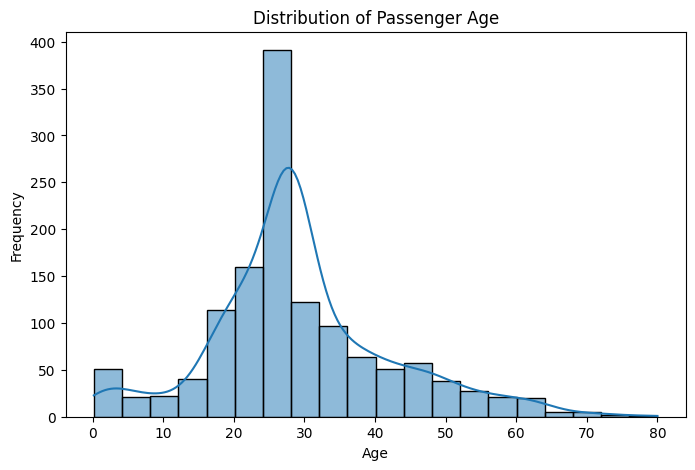

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=20, kde=True)

plt.title("Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

### Histogram Observation

- Most passengers were between **20 and 40 years** of age.
- The age distribution is slightly right-skewed.
- Very few passengers were above 60 years of age.

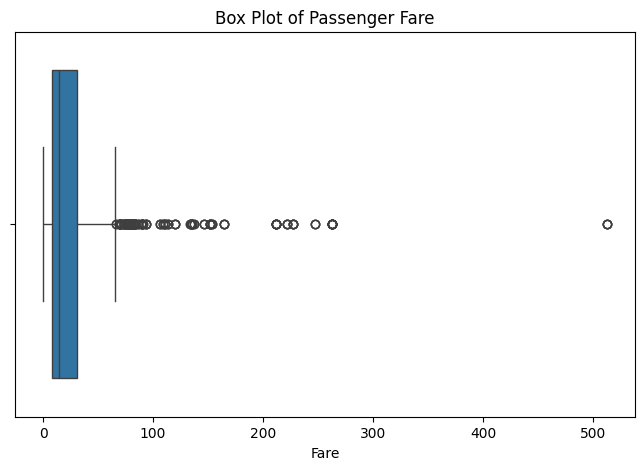

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Fare"])

plt.title("Box Plot of Passenger Fare")

plt.show()

### Box Plot Observation

- Several outliers are present in the Fare column.
- Most passengers paid relatively low fares.
- A few passengers paid significantly higher fares than the majority.

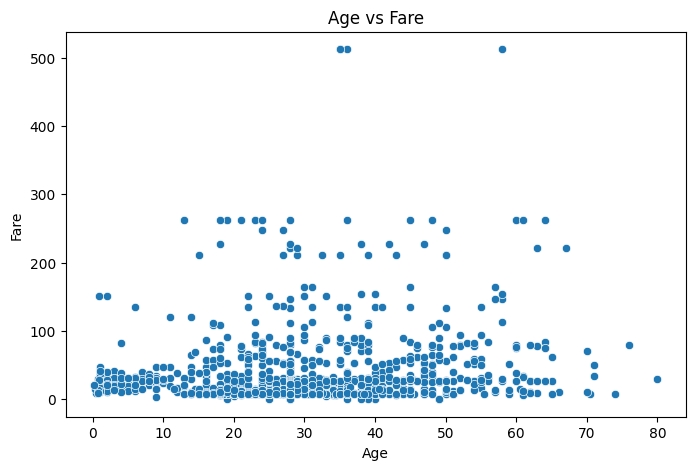

In [14]:
plt.figure(figsize=(8,5))

sns.scatterplot(x="Age", y="Fare", data=df)

plt.title("Age vs Fare")

plt.show()

### Scatter Plot Observation

- There is no strong relationship between passenger age and fare.
- Passengers of different ages paid a wide range of fares.
- Some passengers paid exceptionally high fares irrespective of age.

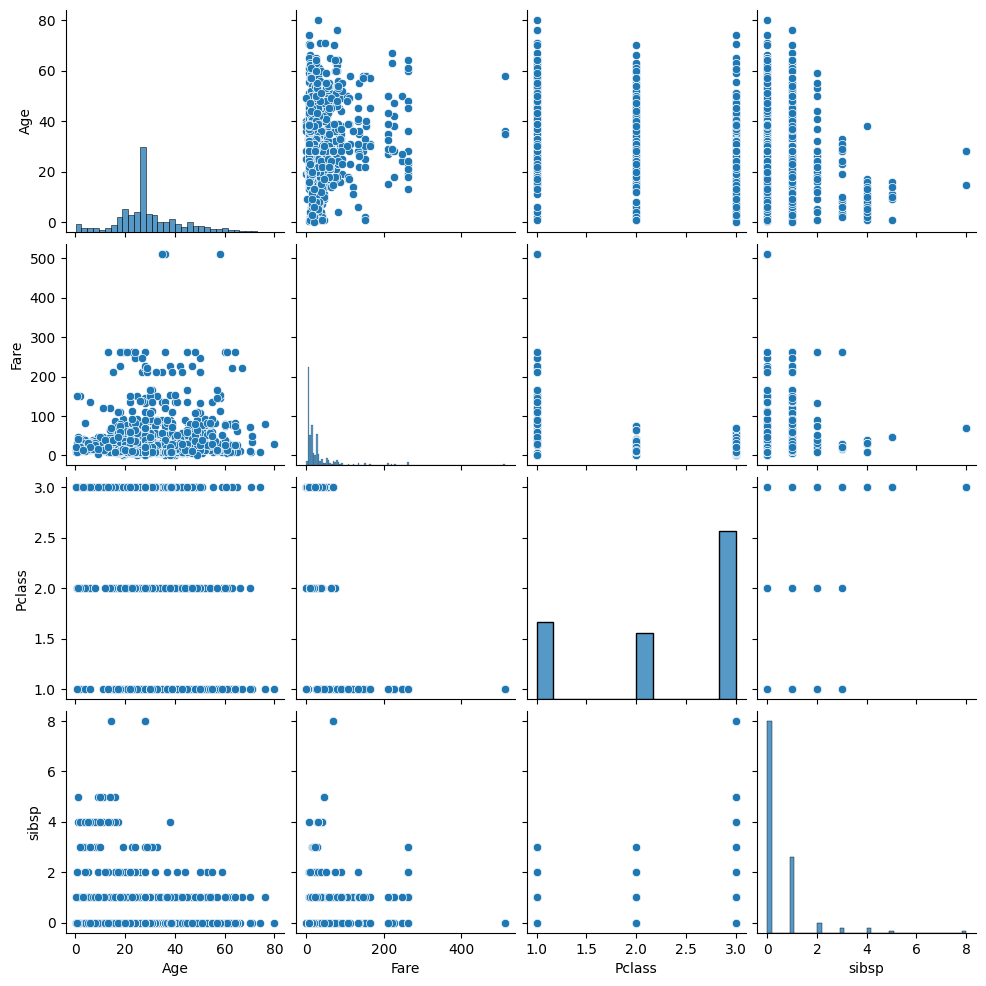

In [15]:
# Pair Plot

selected_columns = ["Age", "Fare", "Pclass", "sibsp"]

sns.pairplot(df[selected_columns])

plt.show()

### Pair Plot Observation

- Age and Fare do not show a strong linear relationship.
- Passengers from different passenger classes paid different fare amounts.
- The selected variables show different distributions, making them useful for further analysis.

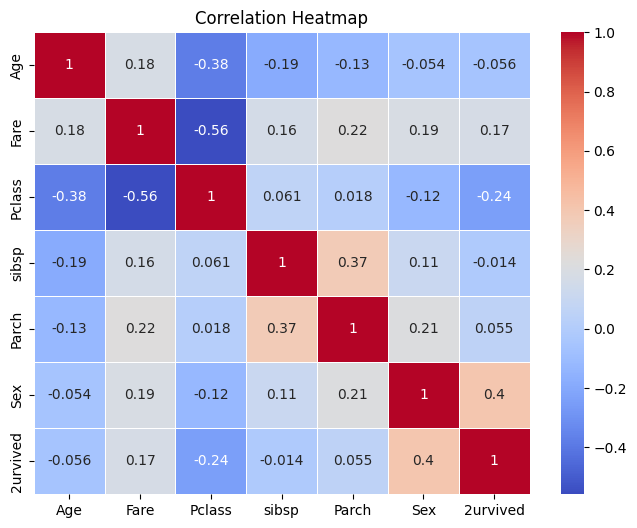

In [16]:
# Correlation Heatmap

plt.figure(figsize=(8,6))

selected = ["Age", "Fare", "Pclass", "sibsp", "Parch", "Sex", "2urvived"]

corr = df[selected].corr()

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            linewidths=0.5)

plt.title("Correlation Heatmap")

plt.show()

### Correlation Heatmap Observation

- Fare and Passenger Class show a negative correlation, indicating that higher-class passengers generally paid higher fares.
- Age has a weak correlation with most other variables.
- Survival shows some relationship with Passenger Class and Sex, suggesting these features may be useful for classification.

# Part D: Descriptive Statistics

Descriptive statistics summarize the central tendency, variability, and distribution of numerical variables. The following statistics are calculated for the main numerical features of the Titanic dataset.

In [17]:
# Select numerical columns for statistical analysis

numerical_columns = ["Age", "Fare", "sibsp", "Parch"]

statistics = pd.DataFrame({
    "Mean": df[numerical_columns].mean(),
    "Median": df[numerical_columns].median(),
    "Mode": df[numerical_columns].mode().iloc[0],
    "Variance": df[numerical_columns].var(),
    "Standard Deviation": df[numerical_columns].std(),
    "Range": df[numerical_columns].max() - df[numerical_columns].min(),
    "IQR": df[numerical_columns].quantile(0.75) - df[numerical_columns].quantile(0.25),
    "Skewness": df[numerical_columns].skew(),
    "Kurtosis": df[numerical_columns].kurt()
})

statistics

,Mean,Median,Mode,Variance,Standard Deviation,Range,IQR,Skewness,Kurtosis
Age,29.503186,28.0000,28.00,166.545235,12.905241,79.8300,13.0000,0.540987,0.969907
Fare,33.281086,14.4542,8.05,2677.182798,51.741500,512.3292,23.3792,4.369510,27.049667
sibsp,0.498854,0.0000,0.00,1.085052,1.041658,8.0000,1.0000,3.844220,20.043251
Parch,0.385027,0.0000,0.00,0.749195,0.865560,9.0000,0.0000,3.669078,21.541079


### Interpretation

- The **mean** and **median** values indicate the central tendency of each numerical feature.
- The **Fare** variable has a high variance and standard deviation, showing that passenger fares vary considerably.
- The **Range** and **Interquartile Range (IQR)** indicate the spread of the data and help identify variability.
- Positive **skewness** in the Fare variable suggests that most passengers paid lower fares, while a few paid very high fares.
- High **kurtosis** in the Fare variable indicates the presence of extreme values (outliers).

# Part E: Data Preprocessing

Data preprocessing improves the quality of the dataset before applying machine learning algorithms. The preprocessing steps performed include handling missing values, removing unnecessary features, encoding categorical variables, and standardizing numerical features.

In [18]:
# Handle missing values

df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

print("Missing values after treatment:")
print(df.isnull().sum())

Missing values after treatment:
Passengerid    0
Age            0
Fare           0
Sex            0
sibsp          0
zero           0
zero.1         0
zero.2         0
zero.3         0
zero.4         0
zero.5         0
zero.6         0
Parch          0
zero.7         0
zero.8         0
zero.9         0
zero.10        0
zero.11        0
zero.12        0
zero.13        0
zero.14        0
Pclass         0
zero.15        0
zero.16        0
Embarked       0
zero.17        0
zero.18        0
2urvived       0
dtype: int64


### Justification

The **Embarked** column contained only two missing values. These values were replaced using the **mode**, since it is the most appropriate method for filling missing values in a categorical variable while preserving the existing distribution.

In [19]:
# Remove unnecessary 'zero' columns

zero_columns = [col for col in df.columns if "zero" in col]

df.drop(columns=zero_columns, inplace=True)

df.head()

,Passengerid,Age,Fare,Sex,sibsp,Parch,Pclass,Embarked,2urvived
0,1,22.0,7.2500,0,1,0,3,2.0,0
1,2,38.0,71.2833,1,1,0,1,0.0,1
2,3,26.0,7.9250,1,0,0,3,2.0,1
3,4,35.0,53.1000,1,1,0,1,2.0,1
4,5,35.0,8.0500,0,0,0,3,2.0,0


### Justification

The dataset contained several columns named **zero**, **zero.1**, **zero.2**, etc. These columns contained only constant values and did not provide any useful information. Therefore, they were removed to simplify the dataset and improve analysis.

In [20]:
# Rename target column

df.rename(columns={"2urvived": "Survived"}, inplace=True)

df.columns

Index(['Passengerid', 'Age', 'Fare', 'Sex', 'sibsp', 'Parch', 'Pclass',
       'Embarked', 'Survived'],
      dtype='object')

### Justification

The target column was renamed from **2urvived** to **Survived** to improve readability and maintain standard naming conventions used in machine learning.

In [21]:
# Check data types

df.dtypes

,0
Passengerid,int64
Age,float64
Fare,float64
Sex,int64
sibsp,int64
Parch,int64
Pclass,int64
Embarked,float64
Survived,int64


### Justification

The categorical variables in this dataset were already represented using numerical values. Therefore, no additional encoding was required.

In [22]:
# Standardize numerical columns

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numerical_features = ["Age", "Fare", "sibsp", "Parch"]

df[numerical_features] = scaler.fit_transform(df[numerical_features])

df.head()

,Passengerid,Age,Fare,Sex,sibsp,Parch,Pclass,Embarked,Survived
0,1,-0.581628,-0.503291,0,0.481288,-0.445,3,2.0,0
1,2,0.658652,0.734744,1,0.481288,-0.445,1,0.0,1
2,3,-0.271558,-0.490240,1,-0.479087,-0.445,3,2.0,1
3,4,0.426099,0.383183,1,0.481288,-0.445,1,2.0,1
4,5,0.426099,-0.487824,0,-0.479087,-0.445,3,2.0,0


### Justification

The numerical features were standardized using **StandardScaler** so that they have a mean close to 0 and a standard deviation close to 1. Standardization ensures that variables measured on different scales contribute equally during machine learning model training.

In [23]:
print("Dataset Shape after Preprocessing:")
print(df.shape)

Dataset Shape after Preprocessing:
(1309, 9)


# Part F: Sampling

Sampling is used to obtain representative subsets of a dataset for analysis. In this section, both Simple Random Sampling and Stratified Sampling are performed and compared using descriptive statistics.

In [24]:
# Simple Random Sampling (20%)

simple_sample = df.sample(frac=0.2, random_state=42)

print("Simple Random Sample Shape:")
print(simple_sample.shape)

Simple Random Sample Shape:
(262, 9)


In [25]:
from sklearn.model_selection import train_test_split

# Stratified Sampling based on Survived

stratified_sample, _ = train_test_split(
    df,
    test_size=0.8,
    stratify=df["Survived"],
    random_state=42
)

print("Stratified Sample Shape:")
print(stratified_sample.shape)

Stratified Sample Shape:
(261, 9)


In [26]:
comparison = pd.DataFrame({
    "Original Mean Age": [df["Age"].mean()],
    "Random Sample Mean Age": [simple_sample["Age"].mean()],
    "Stratified Sample Mean Age": [stratified_sample["Age"].mean()],

    "Original Mean Fare": [df["Fare"].mean()],
    "Random Sample Mean Fare": [simple_sample["Fare"].mean()],
    "Stratified Sample Mean Fare": [stratified_sample["Fare"].mean()]
})

comparison

,Original Mean Age,Random Sample Mean Age,Stratified Sample Mean Age,Original Mean Fare,Random Sample Mean Fare,Stratified Sample Mean Fare
0,3.358658e-17,-0.022857,-0.028634,-2.442660e-17,-0.00374,-0.062105


### Observation

- Both sampling techniques produced representative subsets of the original dataset.
- Stratified sampling preserved the class distribution of the target variable better than simple random sampling.
- The statistical properties of both samples were close to those of the original dataset.

# Part G: Conclusion

### Major Insights

- The Titanic dataset contains a combination of numerical and categorical features suitable for exploratory data analysis.
- Most passengers were between 20 and 40 years of age.
- Passenger fares showed significant variability with several outliers.
- Passenger class and gender exhibited stronger relationships with survival than age.

### Data Quality Issues

- Only two missing values were found in the Embarked column.
- Several unnecessary columns containing constant values were removed during preprocessing.
- No duplicate records were found.

### Important Relationships

- Passenger Class and Fare showed a noticeable negative correlation.
- Survival was moderately associated with passenger class and gender.
- Age showed only weak correlations with the remaining variables.

### Suitability for Machine Learning

The dataset is suitable for machine learning because it contains labelled data, a sufficient number of records, numerical and categorical features, and has been successfully preprocessed for further modelling.

# AI Ethical Usage Declaration

I declare that this assignment is my original work. Any Generative AI tools (such as ChatGPT, Gemini, GitHub Copilot, or similar) were used only to assist with learning, debugging, or improving code readability. I have independently verified all code, analysis, visualisations, interpretations, and conclusions presented in this notebook. Any external resources or AI assistance used have been appropriately acknowledged.